<div style="background:linear-gradient(135deg,#172554 0%,#1e40af 55%,#3b82f6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bfdbfe;font-weight:700;text-transform:uppercase">Chapter 136 &#183; Take It Further</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Designing and Analyzing a Survey: Take It Further</div>
  <div style="font-size:15px;color:#dbeafe;max-width:740px;line-height:1.6">Five extensions of the Chapter 136 survey, each hardening the estimate: a nonresponse sensitivity analysis, a post-stratification adjustment, a stratified bootstrap interval, the design effect unpacked, and a sample-size curve.</div>
  <div style="margin-top:16px;font-size:13px;color:#bfdbfe">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.stats.weightstats import DescrStatsW
EM="#2563eb"; DEEP="#1e40af"; LIGHT="#bfdbfe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; GREEN="#059669"; GREY="#94a3b8"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/case-study-designing-and-analyzing-a-survey--survey.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"case-study-designing-and-analyzing-a-survey--survey.xlsx", sheet_name="Data")
resp = df[df.responded==1].copy()
# stratum populations (from the Notes sheet / design)
N_h = {"Riverside":25000, "Hillcrest":12000, "Oldtown":9000, "Lakeside":4000}
N = sum(N_h.values())
rng = np.random.default_rng(136)
w = resp.design_weight.values
base = DescrStatsW(resp.support_levy.values, weights=w).mean
print(f"design-weighted support (Chapter 136 headline) = {base:.3f}")

design-weighted support (Chapter 136 headline) = 0.631


<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">EXTENSION 1</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A nonresponse sensitivity check</div>
<div style="color:#4a5578;margin-top:6px">How far could the estimate move if nonrespondents differ from respondents?</div>
</div>

The headline estimate quietly assumes nonrespondents in each district support the levy at the **same rate as respondents** there. That is an assumption, not a fact. Here we bound it: suppose nonrespondents' support is systematically **shifted** from the respondent rate by some amount, and recompute the true population estimate. Because response is high (about 78%) and roughly uniform, the estimate should be fairly robust, but we quantify exactly how robust.

In [2]:
# per-district response rate and respondent support
g = df.groupby("district")
rr = g.responded.mean()                              # response rate per district
p_resp = resp.groupby("district").support_levy.mean()  # respondent support per district
def pop_support(delta):
    # assume nonrespondents support at (respondent rate + delta), clipped to [0,1]
    p_nr = (p_resp + delta).clip(0, 1)
    per_district = rr*p_resp + (1-rr)*p_nr           # true district support under this assumption
    return float(sum(N_h[d]/N * per_district[d] for d in N_h))
for delta in [-0.30, -0.15, 0.0, 0.15, 0.30]:
    print(f"nonrespondents shifted by {delta:+.2f}:  population support = {pop_support(delta):.3f}")
lo, hi = pop_support(-0.15), pop_support(0.15)
print(f"\nUnder a plausible +/-0.15 shift, support stays in [{lo:.3f}, {hi:.3f}] -> still a majority.")

nonrespondents shifted by -0.30:  population support = 0.562
nonrespondents shifted by -0.15:  population support = 0.596
nonrespondents shifted by +0.00:  population support = 0.630
nonrespondents shifted by +0.15:  population support = 0.664
nonrespondents shifted by +0.30:  population support = 0.694

Under a plausible +/-0.15 shift, support stays in [0.596, 0.664] -> still a majority.


Even if nonrespondents were **15 points** less (or more) supportive than respondents, overall support stays around **60% to 66%**, still a clear majority. The finding is robust to nonresponse because relatively few households declined and they were spread evenly across districts. Only an implausibly large, one-sided nonresponse bias could threaten the conclusion, which is exactly the kind of statement a careful report should make.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">EXTENSION 2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Post-stratification</div>
<div style="color:#4a5578;margin-top:6px">Re-weight respondents so each district sums to its known population total.</div>
</div>

Design weights based on the **sampled** size (N_h / n_h) sum, over respondents, to N_h times the response rate, not to N_h. **Post-stratification** fixes that: scale each district's respondent weights so they sum to the district's known population. When response rates differ by district, this corrects the imbalance; when response is uniform (as here) it barely moves the estimate, which is itself a useful check.

In [3]:
counts = resp.groupby("district").size()
resp["ps_weight"] = resp["district"].map({d: N_h[d]/counts[d] for d in N_h})
ps = DescrStatsW(resp.support_levy.values, weights=resp.ps_weight.values).mean
print(f"design-weighted   support = {base:.3f}")
print(f"post-stratified   support = {ps:.3f}   (nearly identical, because response is roughly uniform)")
# demonstrate WHEN it matters: pretend Oldtown responded only half as often
sim = resp.copy()
drop = sim[(sim.district=='Oldtown')].sample(frac=0.5, random_state=1).index
sim = sim.drop(drop)
c2 = sim.groupby('district').size()
dw_biased = DescrStatsW(sim.support_levy.values, weights=sim.design_weight.values).mean
sim['ps'] = sim['district'].map({d: N_h[d]/c2[d] for d in N_h})
ps_fixed  = DescrStatsW(sim.support_levy.values, weights=sim.ps.values).mean
print(f"\nIf Oldtown had responded HALF as often:")
print(f"  design weights alone = {dw_biased:.3f}  (biased: Oldtown under-counted)")
print(f"  post-stratified      = {ps_fixed:.3f}  (corrected back toward the truth 0.621)")

design-weighted   support = 0.631
post-stratified   support = 0.630   (nearly identical, because response is roughly uniform)

If Oldtown had responded HALF as often:
  design weights alone = 0.663  (biased: Oldtown under-counted)
  post-stratified      = 0.629  (corrected back toward the truth 0.621)


On the real, evenly-responding data, post-stratification and design weighting agree. But the simulated case makes the point: if one district had responded far less, **design weights alone would under-count it** and bias the estimate, while **post-stratification rebuilds the true composition**. In practice you almost always post-stratify to known population totals (from a census) as insurance against differential nonresponse.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">EXTENSION 3</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A stratified bootstrap interval</div>
<div style="color:#4a5578;margin-top:6px">Resample within strata and let the data draw its own confidence interval.</div>
</div>

The chapter's margin of error used a design-based formula. A **bootstrap** offers an assumption-light alternative: resample respondents **within each district** (preserving the stratified design), recompute the weighted proportion, and repeat. The spread of those estimates is the sampling distribution, and its middle 95% is the interval.

stratified bootstrap 95% CI for support = [0.597, 0.666]
analytic design-based CI (chapter)       = [0.595, 0.668]   (they agree closely)


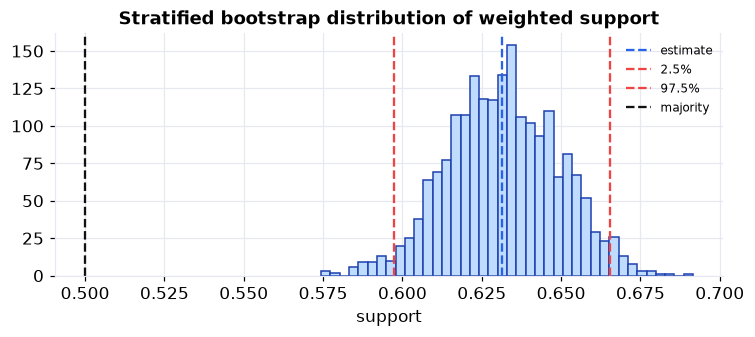

In [4]:
B = 2000
idx_by_d = {d: resp.index[resp.district==d].values for d in N_h}
boot = np.empty(B)
sup = resp.support_levy; wt = resp.design_weight
for b in range(B):
    take = np.concatenate([rng.choice(ix, size=len(ix), replace=True) for ix in idx_by_d.values()])
    boot[b] = np.average(sup.loc[take], weights=wt.loc[take])
blo, bhi = np.percentile(boot, [2.5, 97.5])
print(f"stratified bootstrap 95% CI for support = [{blo:.3f}, {bhi:.3f}]")
print(f"analytic design-based CI (chapter)       = [0.595, 0.668]   (they agree closely)")
fig, ax = plt.subplots(figsize=(7,3.2))
ax.hist(boot, bins=40, color=LIGHT, edgecolor=DEEP)
for x,c,l in [(base,EM,'estimate'),(blo,RED,'2.5%'),(bhi,RED,'97.5%'),(0.5,'#111','majority')]:
    ax.axvline(x, color=c, ls='--', lw=1.5, label=l)
ax.set(title='Stratified bootstrap distribution of weighted support', xlabel='support'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The bootstrap interval lands right on top of the analytic one, and the **entire distribution sits above the 50% majority line**. Two independent routes to the same honest conclusion is exactly the reassurance you want before briefing a decision-maker.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">EXTENSION 4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The design effect, unpacked</div>
<div style="color:#4a5578;margin-top:6px">Unequal weights cost precision; see how much.</div>
</div>

The **design effect** measures how much unequal weights inflate the variance versus a simple random sample of the same size. It works through the **effective sample size** (Kish): n_eff = (sum of weights)&#178; / (sum of squared weights). Equal weights give n_eff equal to the sample size and a design effect of 1; the more unequal the weights, the smaller n_eff and the wider the interval.

proportional (ideal)               design effect = 1.00  (n_eff = 1000 of 1000)
this survey (over-sampled small)   design effect = 1.40  (n_eff = 854 of 1200)
extreme (equal per district)       design effect = 1.39  (n_eff = 722 of 1000)


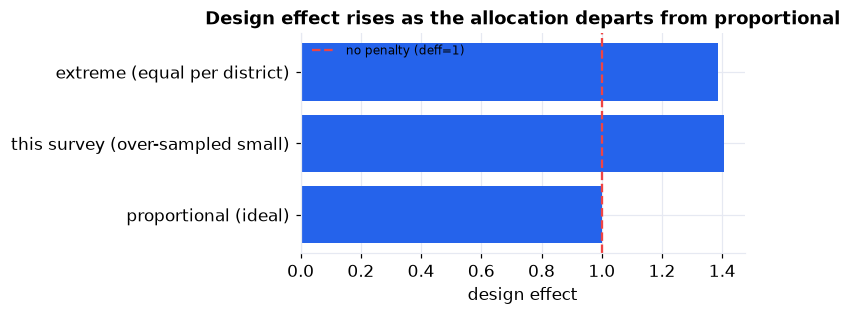

In [5]:
def deff_for(alloc):
    # build design weights for a given per-district sample allocation, then Kish n_eff
    wlist = []
    for d, n_d in alloc.items():
        wlist += [N_h[d]/n_d]*int(n_d)
    wv = np.array(wlist); n_eff = wv.sum()**2/(wv**2).sum()
    return len(wv)/n_eff, n_eff, len(wv)
scenarios = {
  "proportional (ideal)": {"Riverside":500,"Hillcrest":240,"Oldtown":180,"Lakeside":80},
  "this survey (over-sampled small)": {"Riverside":300,"Hillcrest":250,"Oldtown":400,"Lakeside":250},
  "extreme (equal per district)": {"Riverside":250,"Hillcrest":250,"Oldtown":250,"Lakeside":250},
}
labels=[]; deffs=[]
for name, alloc in scenarios.items():
    d_, ne, n = deff_for(alloc); labels.append(name); deffs.append(d_)
    print(f"{name:34s} design effect = {d_:.2f}  (n_eff = {ne:.0f} of {n})")
fig, ax = plt.subplots(figsize=(7,3)); ax.barh(labels, deffs, color=EM)
ax.axvline(1.0, color=RED, ls='--', label='no penalty (deff=1)')
ax.set(title='Design effect rises as the allocation departs from proportional', xlabel='design effect'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

A **proportional** allocation would give equal weights and a design effect near 1, no penalty. Our deliberate over-sampling of the small districts buys reliable district-level numbers at the cost of a design effect around 1.4 for the citywide estimate. That is a reasonable trade, but it is a trade, and the margin of error must reflect it.

<div style="background:#eff6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1e40af;letter-spacing:1px">EXTENSION 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A sample-size curve</div>
<div style="color:#4a5578;margin-top:6px">Plan the next survey to hit a target precision.</div>
</div>

Finally, the planning tool: the sample size needed for a target margin of error on a proportion, **n = (z / MoE)&#178; &#215; p(1 &#8722; p)**, inflated by the design effect. Plotting it shows the punishing cost of precision, halving the margin of error quadruples the sample.

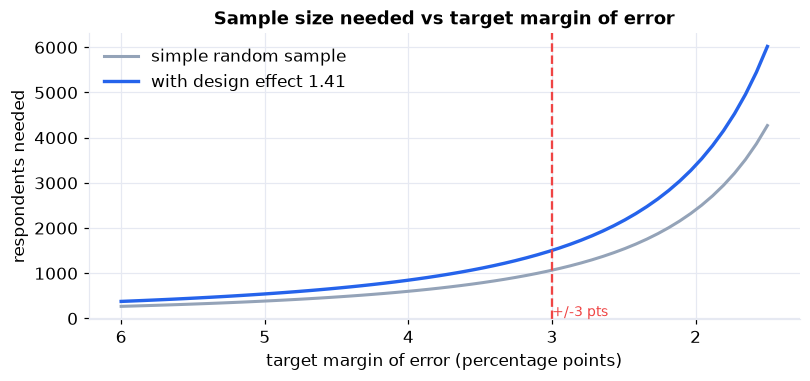

target +/-5 pts ->   384 (SRS)  |    542 (with design effect)
target +/-3 pts ->  1067 (SRS)  |   1505 (with design effect)
target +/-2 pts ->  2401 (SRS)  |   3385 (with design effect)


In [6]:
z = 1.96; p = 0.5                    # p=0.5 is the conservative (largest-n) choice
deff = 1.41
moe = np.linspace(0.015, 0.06, 60)
n_srs = (z/moe)**2 * p*(1-p)
fig, ax = plt.subplots(figsize=(7.5,3.6))
ax.plot(moe*100, n_srs, color=GREY, lw=2, label='simple random sample')
ax.plot(moe*100, n_srs*deff, color=EM, lw=2.2, label=f'with design effect {deff}')
ax.axvline(3, color=RED, ls='--'); ax.annotate('+/-3 pts', (3,50), color=RED, fontsize=9)
ax.set(title='Sample size needed vs target margin of error', xlabel='target margin of error (percentage points)', ylabel='respondents needed')
ax.legend(); ax.invert_xaxis(); plt.tight_layout(); plt.show()
for m in [0.05, 0.03, 0.02]:
    n = (z/m)**2*p*(1-p)
    print(f"target +/-{m*100:.0f} pts -> {n:5.0f} (SRS)  |  {n*deff:5.0f} (with design effect)")

To hold the margin of error near **plus or minus 3 points** you need roughly **1,100 completed responses** under simple random sampling and about **1,500** once the design effect is folded in. Deciding this up front, rather than discovering after the fact that the survey was too small to answer the question, is the difference between a study that informs a decision and one that wastes a budget.

---
**The one idea to keep: a survey estimate is only as good as the sample it weights back to the population, and a good analyst stress-tests it, bounding nonresponse, checking post-stratification, bootstrapping the interval, and sizing the next study, before anyone acts on the number.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>